In [ ]:
# Goal: Image / Video auto-encoding, and test SoRL on them
# ----------------------------------------------------------



In [1]:
from dataclasses import dataclass
from itertools import cycle
from typing import Tuple

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class VideoConfig:
    frames: int = 8
    size: int = 32
    dataset_len: int = 512
    batch_size: int = 32


def _make_grid(size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    coords = torch.linspace(-1.0, 1.0, size)
    grid_y, grid_x = torch.meshgrid(coords, coords, indexing="ij")
    return grid_y, grid_x


class MovingBlobDataset(Dataset):
    def __init__(self, cfg: VideoConfig):
        self.cfg = cfg
        self.grid_y, self.grid_x = _make_grid(cfg.size)
        self.sigma = 0.12

    def __len__(self) -> int:
        return self.cfg.dataset_len

    def _draw_blob(self, center: torch.Tensor) -> torch.Tensor:
        dist2 = (self.grid_x - center[0]) ** 2 + (self.grid_y - center[1]) ** 2
        frame = torch.exp(-dist2 / (2 * self.sigma**2))
        return frame.unsqueeze(0)

    def __getitem__(self, idx: int) -> torch.Tensor:  # noqa: ARG002
        cfg = self.cfg
        base = torch.rand(2) * 1.4 - 0.7
        velocity = (torch.rand(2) - 0.5) * 0.6
        times = torch.linspace(-0.6, 0.6, cfg.frames).unsqueeze(1)
        centers = (base + times * velocity).clamp(-0.9, 0.9)
        video = torch.stack([self._draw_blob(c) for c in centers], dim=0)
        noise = torch.randn_like(video) * 0.02
        video = (video + noise).clamp(0.0, 1.0)
        return video.permute(1, 0, 2, 3)  # -> (C, T, H, W)


cfg = VideoConfig()
dataset = MovingBlobDataset(cfg)
dataloader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
train_stream = cycle(dataloader)

In [2]:
class TinyVideoAE(nn.Module):
    def __init__(self, latent_dim: int = 96, focus_temperature: float = 1.0):
        super().__init__()
        self.focus_temperature = focus_temperature
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(16, 32, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.GELU(),
        )
        encoded_dim = 64 * 2 * 4 * 4
        self.enc_norm = nn.LayerNorm(encoded_dim)
        self.to_latent = nn.Linear(encoded_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, encoded_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=(2, 2, 2), padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(16, 8, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

        self.focus_head = nn.Sequential(
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=(2, 2, 2), padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(16, 8, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(8, 1, kernel_size=3, padding=1),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x).flatten(1)
        return self.to_latent(self.enc_norm(h))

    def project_latent(self, z: torch.Tensor) -> torch.Tensor:
        return self.from_latent(z).view(-1, 64, 2, 4, 4)

    def decode(self, decoded_features: torch.Tensor) -> torch.Tensor:
        return self.decoder(decoded_features)

    def focus_from_features(self, decoded_features: torch.Tensor) -> torch.Tensor:
        logits = self.focus_head(decoded_features) / self.focus_temperature
        b = logits.shape[0]
        focus = torch.softmax(logits.view(b, -1), dim=1).view_as(logits)
        return focus

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        latent = self.encode(x)
        decoded_features = self.project_latent(latent)
        recon = self.decode(decoded_features)
        focus = self.focus_from_features(decoded_features)
        return recon, focus


def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


model = TinyVideoAE().to(device)
print(f"TinyVideoAE params: {count_parameters(model)/1e6:.2f} M")



TinyVideoAE params: 0.81 M


step 0050/800 | ae_loss=0.0284 | weighted_err=0.0284
step 0100/800 | ae_loss=0.0283 | weighted_err=0.0283
step 0150/800 | ae_loss=0.0284 | weighted_err=0.0284
step 0200/800 | ae_loss=0.0284 | weighted_err=0.0284
step 0250/800 | ae_loss=0.0395 | weighted_err=0.0395
step 0300/800 | ae_loss=0.0907 | weighted_err=0.0907
step 0350/800 | ae_loss=0.0597 | weighted_err=0.0597
step 0400/800 | ae_loss=0.0521 | weighted_err=0.0521
step 0450/800 | ae_loss=0.1069 | weighted_err=0.1069
step 0500/800 | ae_loss=0.0680 | weighted_err=0.0680
step 0550/800 | ae_loss=0.0639 | weighted_err=0.0639
step 0600/800 | ae_loss=0.0353 | weighted_err=0.0353
step 0650/800 | ae_loss=0.0357 | weighted_err=0.0357
step 0700/800 | ae_loss=0.1082 | weighted_err=0.1082
step 0750/800 | ae_loss=0.1162 | weighted_err=0.1162
step 0800/800 | ae_loss=0.0376 | weighted_err=0.0376


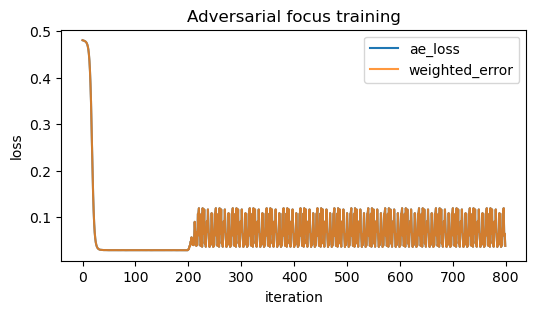

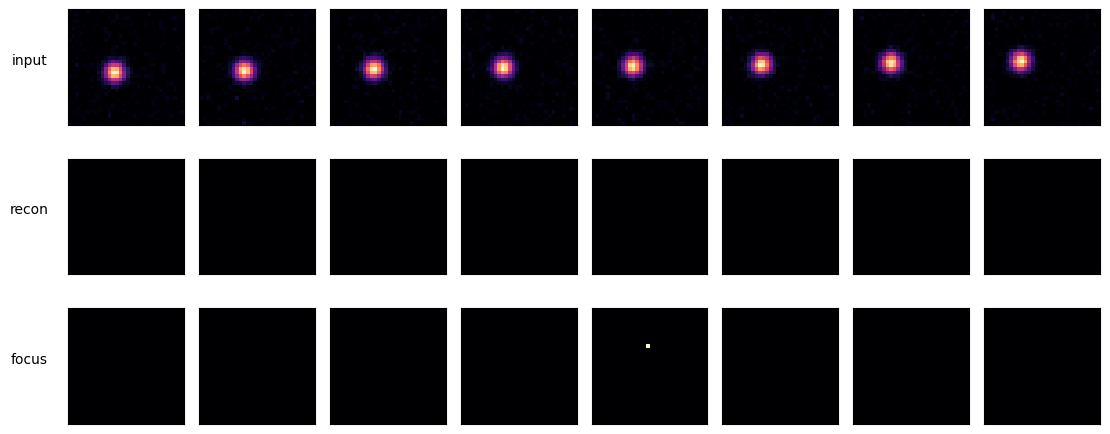

In [3]:
train_steps = 800
focus_warmup_steps = 200
focus_interval = 2
focus_updates = 3
criterion_pixelwise = nn.L1Loss(reduction="none")

focus_params = list(model.focus_head.parameters())
ae_params = [
    param
    for name, param in model.named_parameters()
    if not name.startswith("focus_head")
]

optimizer_ae = torch.optim.AdamW(ae_params, lr=3e-4, weight_decay=1e-4)
optimizer_focus = torch.optim.AdamW(focus_params, lr=3e-4, weight_decay=1e-4)

history_ae: list[float] = []
history_focus: list[float] = []


def set_requires_grad(module: nn.Module, requires_grad: bool) -> None:
    for param in module.parameters():
        param.requires_grad = requires_grad


def reduce_weighted(pixelwise: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (pixelwise * weights).sum(dim=(1, 2, 3, 4))


model.train()
for step in range(1, train_steps + 1):
    batch = next(train_stream).to(device)

    # --- Autoencoder (generator) step ---
    set_requires_grad(model.focus_head, False)
    optimizer_ae.zero_grad()

    recon, focus_map = model(batch)
    pixelwise_loss = criterion_pixelwise(recon, batch)

    if step < focus_warmup_steps:
        weighted_err = pixelwise_loss.mean(dim=(1, 2, 3, 4))
    else:
        weighted_err = reduce_weighted(pixelwise_loss, focus_map.detach())

    loss_ae = weighted_err.mean()
    loss_ae.backward()
    nn.utils.clip_grad_norm_(ae_params, 1.0)
    optimizer_ae.step()

    history_ae.append(loss_ae.item())
    history_focus.append(weighted_err.mean().item())

    # --- Focus head (critique) step(s) ---
    if step >= focus_warmup_steps and step % focus_interval == 0:
        set_requires_grad(model.focus_head, True)
        for _ in range(focus_updates):
            batch_focus = next(train_stream).to(device)
            optimizer_focus.zero_grad()

            with torch.no_grad():
                latent = model.encode(batch_focus)
                decoded = model.project_latent(latent)
                recon_detached = model.decode(decoded)
                pixelwise_loss_detached = criterion_pixelwise(recon_detached, batch_focus)

            focus_map = model.focus_from_features(decoded.detach())
            loss_focus = -reduce_weighted(pixelwise_loss_detached, focus_map).mean()

            loss_focus.backward()
            nn.utils.clip_grad_norm_(focus_params, 1.0)
            optimizer_focus.step()

    if step % 50 == 0:
        latest_focus = history_focus[-1]
        print(
            f"step {step:04d}/{train_steps} | ae_loss={loss_ae.item():.4f} | weighted_err={latest_focus:.4f}"
        )

plt.figure(figsize=(6, 3))
plt.plot(history_ae, label="ae_loss")
plt.plot(history_focus, label="weighted_error", alpha=0.8)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Adversarial focus training")
plt.legend()
plt.show()

def visualize_reconstruction(example_idx: int = 0) -> None:
    model.eval()
    with torch.no_grad():
        original = dataset[example_idx].unsqueeze(0).to(device)
        recon, focus = model(original)
    original = original.cpu()
    recon = recon.cpu()
    focus = focus.cpu()

    fig, axes = plt.subplots(3, cfg.frames, figsize=(cfg.frames * 1.4, 4.8))
    for row, tensor, label in zip(axes, (original, recon, focus), ("input", "recon", "focus")):
        for col, ax in enumerate(row):
            ax.imshow(tensor[0, 0, col], cmap="magma", vmin=0, vmax=1)
            if col == 0:
                ax.set_ylabel(label, rotation=0, labelpad=28, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()
    
visualize_reconstruction(example_idx=3)

In [ ]:
# Multi-scale loss 
# --> conv on recon, target --> compute loss